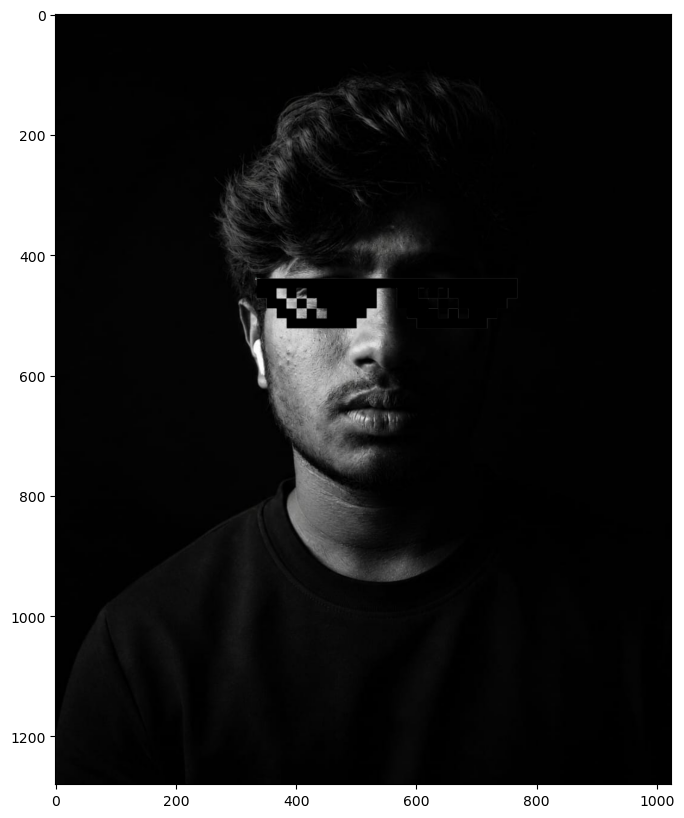

In [33]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Read images
image = cv2.imread("MY PICTURE.jpeg")
glass = cv2.imread("1.png", cv2.IMREAD_UNCHANGED)

# Convert face image to RGB
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Position and size
x = 310
y = 325
width = 500


# Resize glasses
height = int(glass.shape[0] * width / glass.shape[1])
glass = cv2.resize(glass, (width, height))

# ROI
roi = image[y:y+height, x:x+width]

# Alpha channel
alpha = glass[:, :, 3] / 255.0
alpha = np.dstack((alpha, alpha, alpha))

# RGB channels of glasses
glass_rgb = cv2.cvtColor(glass[:, :, :3], cv2.COLOR_BGR2RGB)

# Blend
blended = glass_rgb * alpha + roi * (1 - alpha)

# Place result
result = image.copy()
result[y:y+height, x:x+width] = blended.astype(np.uint8)

# Save
cv2.imwrite(
    "output_sunglasses.jpg",
    cv2.cvtColor(result, cv2.COLOR_RGB2BGR)
)

# Show
plt.figure(figsize=(8,10))
plt.imshow(result)

plt.show()